# Further Research 2 -- State Affordability Convergence

**Research Question:**
How long before a family from a low-income state reaches the same degree affordability
level as a family in KL, if current trends hold?

This notebook examines the question from two angles:

| Part | Scope | Fee basis |
|---|---|---|
| A | Public university pathway | Public fee (UTM, UM average) |
| B | Private university pathway | Private fee range (market estimate) |

**Why two parts?**
In Malaysia, not all students attend public universities. A significant share of
graduates attend private institutions, where fees are substantially higher.
The affordability experience differs considerably between the two groups,
and the convergence timeline for each tells a different story.

**On private fee estimation:**
Our dataset covers only two premium private institutions (APU, Taylor's).
To avoid overstating the burden, Part B presents three scenarios:
- APU/Taylor's average (RM 119k) -- acknowledged as upper bound (premium institutions only)
- Actual market average is likely lower; this is stated as a limitation throughout


## Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from sklearn.linear_model import LinearRegression
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'
TEAL   = '#0D9488'

hh_state = pd.read_csv('../data/cleaned/hh_income_state.csv', parse_dates=['date'])
fees     = pd.read_csv('../data/cost/edunilai_mean_fees.csv')
cpi      = pd.read_csv('../data/cleaned/cpi.csv', parse_dates=['date'])

hh_state['year'] = hh_state['date'].dt.year
cpi['year']      = cpi['date'].dt.year

fees['public_avg']  = fees[['UTM', 'UM']].mean(axis=1)
fees['private_avg'] = fees[["APU", "Taylor's"]].mean(axis=1)

PUBLIC_FEE     = fees['public_avg'].mean()
# Private fee: APU + Taylor's average only (upper bound / premium tier)
# Acknowledged limitation: only two premium institutions in dataset
# This is a conservative upper-bound estimate -- actual market average is likely lower
PRIVATE_FEE = fees['private_avg'].mean()

cpi_edu        = cpi[cpi['division']=='10'].set_index('year')['index']
EDU_CPI_GROWTH = (cpi_edu[2022] / cpi_edu[2012]) ** (1/10) - 1

# Compute affordability index for all states and years
rows = []
for _, row in hh_state.iterrows():
    ann = row['income_median'] * 12
    rows.append({
        'state':        row['state'],
        'year':         row['year'],
        'income_median':row['income_median'],
        'annual_income':ann,
        'aff_public':   PUBLIC_FEE    / ann,
        'aff_private':  PRIVATE_FEE   / ann,
    })
aff_df = pd.DataFrame(rows)

KL_PUBLIC_2022 = aff_df[
    (aff_df['state']=='W.P. Kuala Lumpur') & (aff_df['year']==2022)
]['aff_public'].values[0]

hh_2022 = aff_df[aff_df['year']==2022].copy()

PROJ_YEARS = np.arange(2022, 2071)

print(f"Public fee (mean across fields):        RM {PUBLIC_FEE:>10,.0f}")
print(f"Private fee (APU/Taylors, upper bound): RM {PRIVATE_FEE:>10,.0f}  ({PRIVATE_FEE/PUBLIC_FEE:.1f}x)")
print(f"Note: only premium private institutions in dataset -- actual market average is lower")
print(f"KL public affordability 2022 (target):  {KL_PUBLIC_2022:.4f} years of HH income")


Public fee (mean across fields):        RM     11,229
Private fee (APU/Taylors, upper bound): RM    125,198  (11.1x)
Note: only premium private institutions in dataset -- actual market average is lower
KL public affordability 2022 (target):  0.0914 years of HH income


---
# Part A -- Public University Pathway

Examines how affordable a public degree is across all states,
and how long it takes each state to reach KL's current affordability level.


## A1 -- Affordability Heatmap: All States x All HIES Years

Each cell shows years of full household income needed to pay for a public degree.
Green = affordable. Red = costly relative to local income.

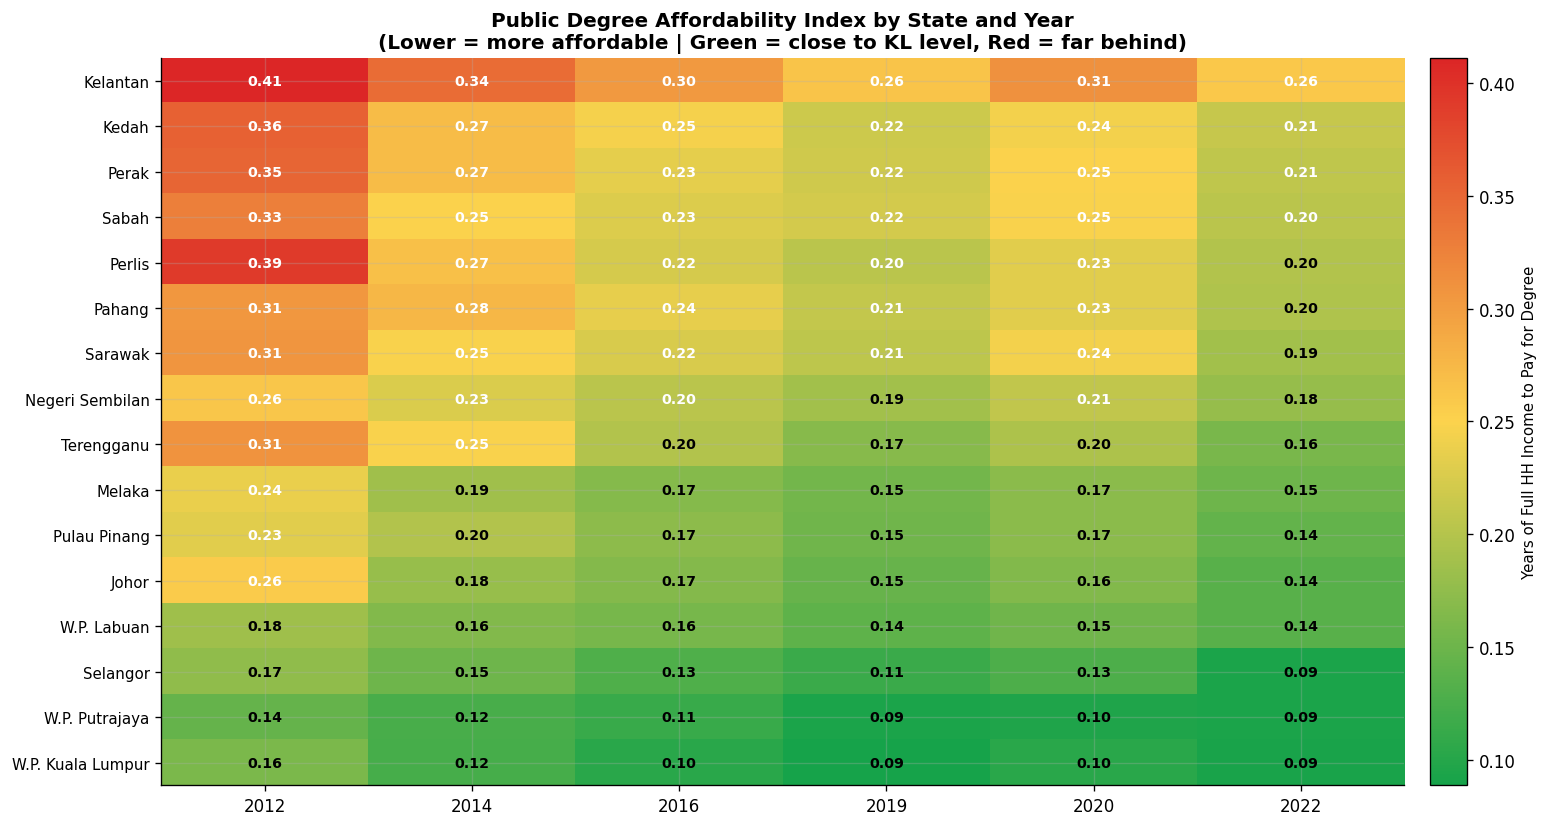

In [23]:
pivot = aff_df.pivot(index='state', columns='year', values='aff_public')
pivot = pivot.sort_values(2022, ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
cmap_heat = LinearSegmentedColormap.from_list('afford', ['#16A34A','#FCD34D','#DC2626'])
im = ax.imshow(pivot.values, aspect='auto', cmap=cmap_heat)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8.5, fontweight='bold',
                    color='white' if val > 0.20 else 'black')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Years of Full HH Income to Pay for Degree', fontsize=9)
ax.set_title('Public Degree Affordability Index by State and Year\n'
             '(Lower = more affordable | Green = close to KL level, Red = far behind)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## A2 -- How Fast Is Each State Improving?

Annual improvement rate from linear regression on each state's affordability index.
Positive = index falling = becoming more affordable each year.

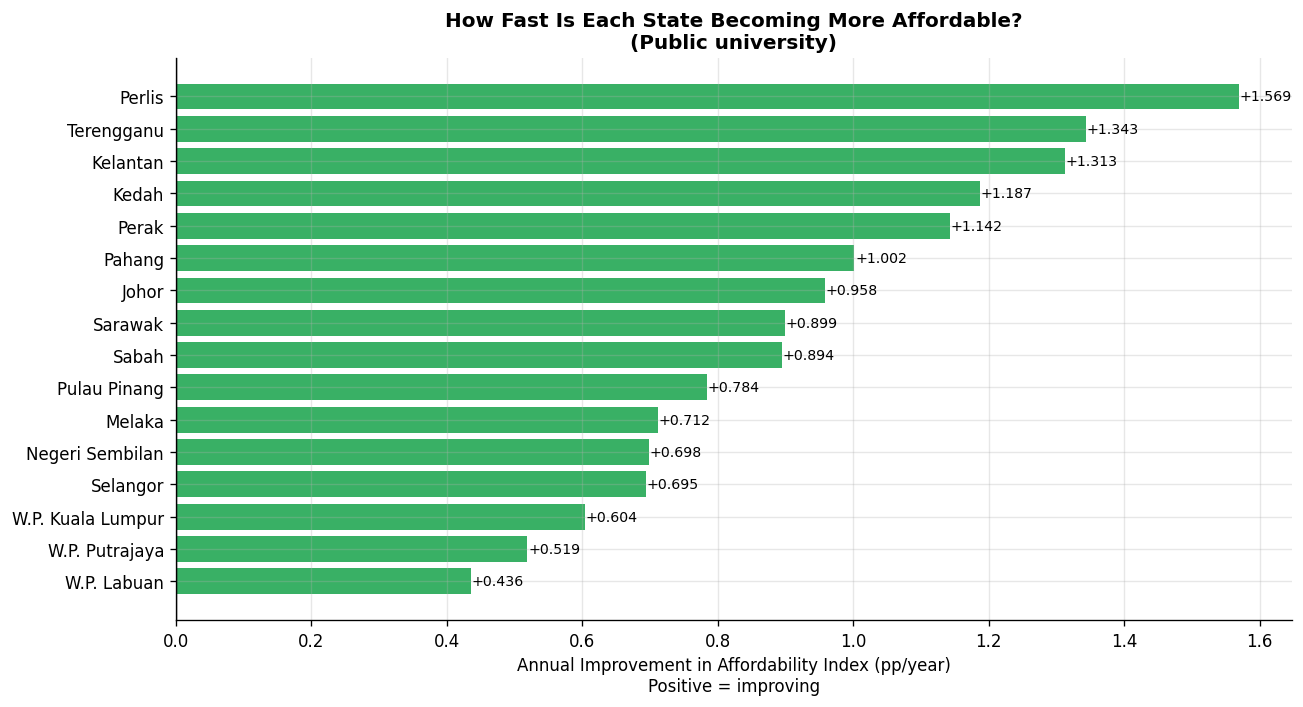

In [24]:
pub_trends = {}
for state in aff_df['state'].unique():
    df_s  = aff_df[aff_df['state']==state].sort_values('year')
    X     = df_s['year'].values.reshape(-1,1)
    y_arr = df_s['aff_public'].values
    model = LinearRegression().fit(X, y_arr)
    pub_trends[state] = {'slope': model.coef_[0], 'intercept': model.intercept_,
                         'model': model, 'data': df_s}

slope_df = pd.DataFrame([
    {'state': s, 'improvement_pp_yr': -v['slope'] * 100}
    for s, v in pub_trends.items()
]).sort_values('improvement_pp_yr', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors_bar = [GREEN if v > 0 else RED for v in slope_df['improvement_pp_yr']]
bars = ax.barh(slope_df['state'], slope_df['improvement_pp_yr'],
               color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Annual Improvement in Affordability Index (pp/year)\nPositive = improving')
ax.set_title('How Fast Is Each State Becoming More Affordable?\n(Public university)',
             fontweight='bold')
for bar, val in zip(bars, slope_df['improvement_pp_yr']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
plt.tight_layout()
plt.show()


## A3 -- Convergence Chart: When Does Each State Reach KL's Level?

Top 5 most burdened states + 2 closest to KL, auto-selected from data.

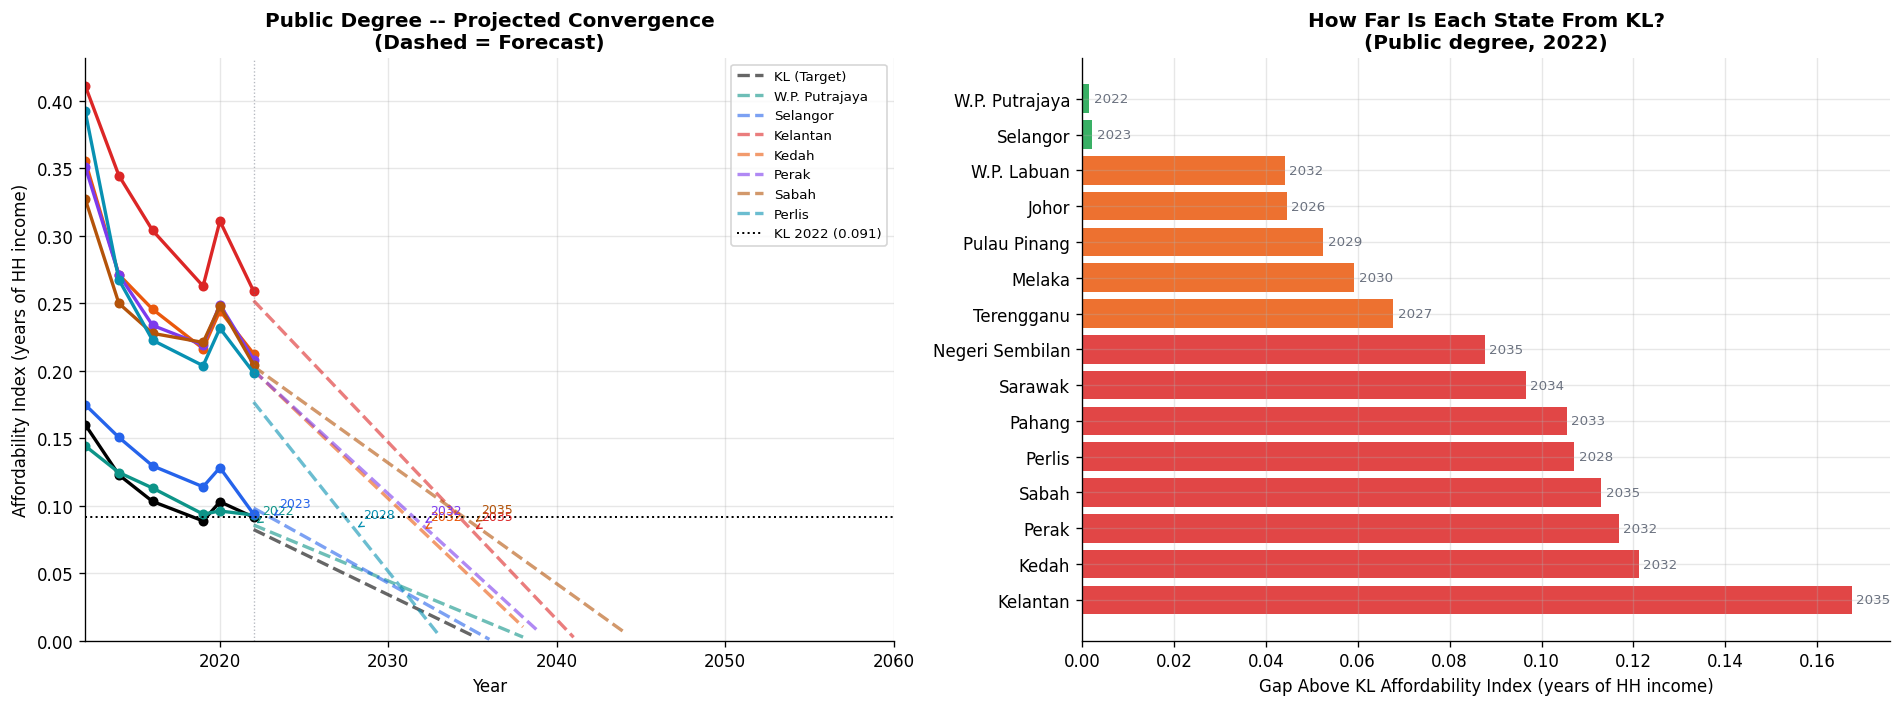

In [25]:
pub_conv = []
for state, t in pub_trends.items():
    if state == 'W.P. Kuala Lumpur': continue
    proj    = t['model'].predict(PROJ_YEARS.reshape(-1,1))
    crossed = PROJ_YEARS[proj <= KL_PUBLIC_2022]
    conv_yr = int(crossed[0]) if len(crossed) > 0 else None
    aff22   = aff_df[(aff_df['state']==state)&(aff_df['year']==2022)]['aff_public'].values[0]
    pub_conv.append({'state': state, 'aff_2022': aff22,
                     'gap': aff22 - KL_PUBLIC_2022, 'conv_year': conv_yr})

pub_conv_df = pd.DataFrame(pub_conv).sort_values('aff_2022', ascending=False)
worst5 = pub_conv_df.nlargest(5,  'aff_2022')['state'].tolist()
best2  = pub_conv_df.nsmallest(2, 'aff_2022')['state'].tolist()
focus  = ['W.P. Kuala Lumpur'] + best2 + worst5
palette = ['black', TEAL, BLUE, RED, ORANGE, PURPLE, '#B45309', '#0891B2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, state in enumerate(focus):
    t     = pub_trends[state]
    hist  = aff_df[aff_df['state']==state].sort_values('year')
    proj  = t['model'].predict(PROJ_YEARS.reshape(-1,1))
    proj_c= np.maximum(proj, 0)
    color = palette[i % len(palette)]
    lbl   = 'KL (Target)' if state == 'W.P. Kuala Lumpur' else state
    mask  = (PROJ_YEARS <= 2060) & (proj >= 0)

    axes[0].plot(hist['year'], hist['aff_public'],
                 color=color, lw=2, ls='-', marker='o', markersize=5)
    axes[0].plot(PROJ_YEARS[mask], proj_c[mask],
                 color=color, lw=2, ls='--', alpha=0.6, label=lbl)

    row = pub_conv_df[pub_conv_df['state']==state]
    if not row.empty and row['conv_year'].values[0]:
        cy = row['conv_year'].values[0]
        if cy <= 2060:
            cv = max(t['model'].predict([[cy]])[0], 0)
            axes[0].annotate(f'{cy}', xy=(cy, cv), xytext=(cy+0.5, cv+0.008),
                fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

axes[0].axhline(KL_PUBLIC_2022, color='black', lw=1.2, ls=':',
                label=f'KL 2022 ({KL_PUBLIC_2022:.3f})')
axes[0].axvline(2022, color=GRAY, lw=0.8, ls=':', alpha=0.5)
axes[0].set_ylim(bottom=0)
axes[0].set_xlim(2012, 2060)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Affordability Index (years of HH income)')
axes[0].set_title('Public Degree -- Projected Convergence\n(Dashed = Forecast)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

gap_df = pub_conv_df.sort_values('gap', ascending=False)
colors_gap = [RED if v > 0.08 else ORANGE if v > 0.04 else GREEN for v in gap_df['gap']]
bars = axes[1].barh(gap_df['state'], gap_df['gap'], color=colors_gap, alpha=0.85)
axes[1].set_xlabel('Gap Above KL Affordability Index (years of HH income)')
axes[1].set_title("How Far Is Each State From KL?\n(Public degree, 2022)",
                  fontweight='bold')
for bar, (_, row) in zip(bars, gap_df.iterrows()):
    lbl = f"{int(row['conv_year'])}" if row['conv_year'] else '>2070'
    axes[1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                 lbl, va='center', fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()


## A4 -- Sensitivity: What If Fees Rise With Education CPI?

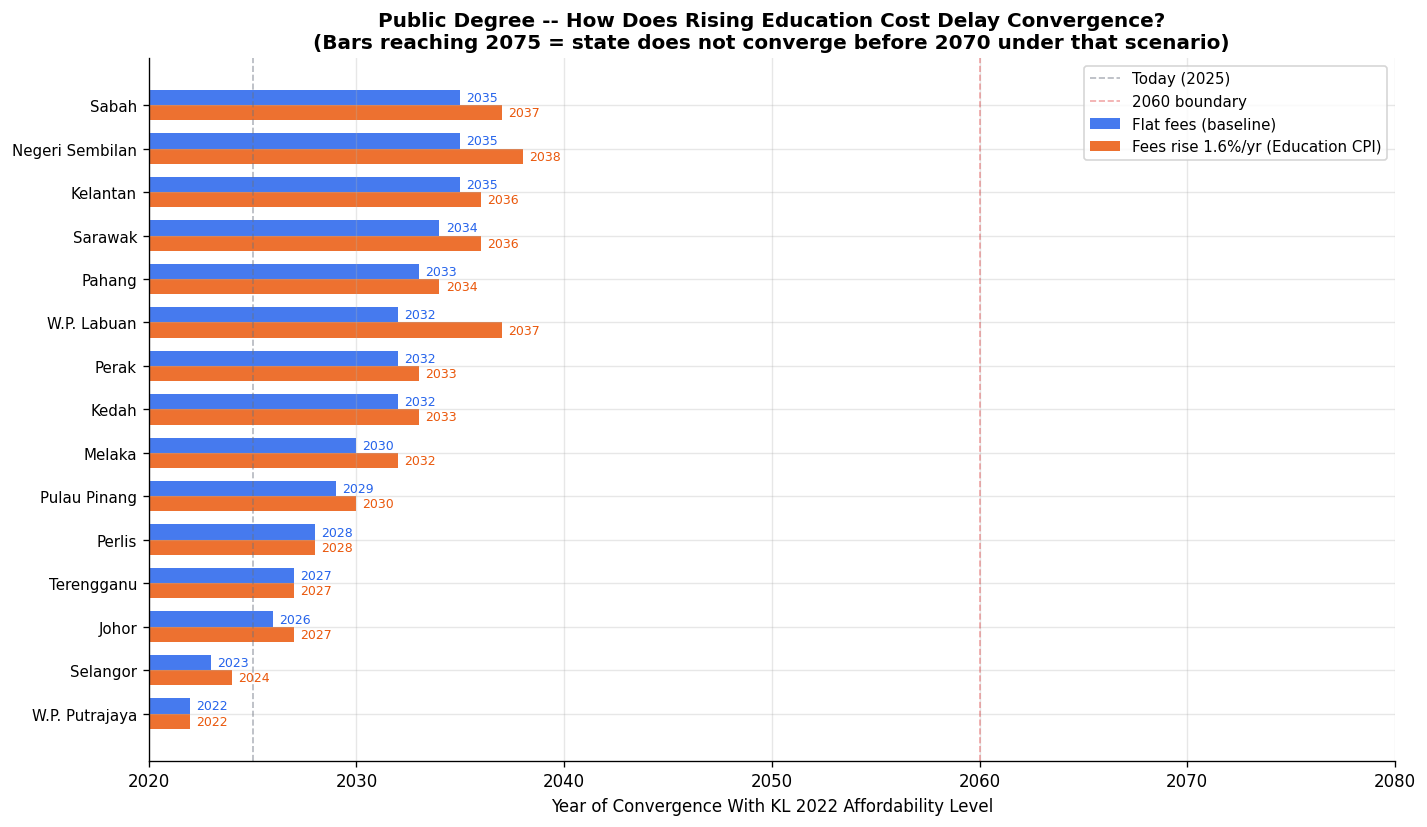

In [26]:
sensitivity_results = []
for state, trend in pub_trends.items():
    if state == 'W.P. Kuala Lumpur':
        continue

    # Step 1: project the affordability index for each future year using the fitted trend
    projected_affordability = trend['model'].predict(PROJ_YEARS.reshape(-1, 1))

    # Step 2: back-calculate implied monthly household income from the projected index
    # Since: affordability_index = fee / annual_income
    # Rearranged: monthly_income = fee / (affordability_index x 12)
    with np.errstate(divide='ignore', invalid='ignore'):
        projected_monthly_income = np.where(
            projected_affordability > 0,
            PUBLIC_FEE / (projected_affordability * 12),
            np.nan
        )

    # Step 3: calculate how much the fee would be each year if it grows at education CPI rate
    years_since_2022 = PROJ_YEARS - 2022
    fee_if_rising    = PUBLIC_FEE * (1 + EDU_CPI_GROWTH) ** years_since_2022

    # Step 4: recalculate affordability index using the rising fee and the same income trajectory
    with np.errstate(divide='ignore', invalid='ignore'):
        affordability_with_rising_fee = np.where(
            projected_monthly_income > 0,
            fee_if_rising / (projected_monthly_income * 12),
            np.nan
        )

    # Step 5: find the first year where affordability reaches KL 2022 level under rising fees
    years_where_converges_rising = PROJ_YEARS[
        (affordability_with_rising_fee <= KL_PUBLIC_2022) &
        ~np.isnan(affordability_with_rising_fee)
    ]
    convergence_year_rising_fees = int(years_where_converges_rising[0]) if len(years_where_converges_rising) > 0 else None

    # Also retrieve the flat-fee convergence year computed in A3
    flat_fee_result = pub_conv_df[pub_conv_df['state'] == state]['conv_year'].values
    convergence_year_flat_fees = flat_fee_result[0] if len(flat_fee_result) > 0 else None

    sensitivity_results.append({
        'state':                      state,
        'convergence_year_flat_fees': convergence_year_flat_fees,
        'convergence_year_rising_fees': convergence_year_rising_fees,
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

# Convert to integer for plotting, use 9999 as placeholder for "does not converge before 2070"
sensitivity_df['flat_fees_plot_value']   = sensitivity_df['convergence_year_flat_fees'].apply(
    lambda year: int(year) if year else 9999)
sensitivity_df['rising_fees_plot_value'] = sensitivity_df['convergence_year_rising_fees'].apply(
    lambda year: int(year) if year else 9999)

# Sort by flat fee convergence year so fastest-converging states appear at top
sensitivity_sorted = sensitivity_df.sort_values('flat_fees_plot_value', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bar_positions    = np.arange(len(sensitivity_sorted))
bar_height       = 0.35

# Replace 9999 with 2075 so bars for non-converging states extend to the right edge
flat_fees_values   = sensitivity_sorted['flat_fees_plot_value'].values.astype(float)
rising_fees_values = sensitivity_sorted['rising_fees_plot_value'].values.astype(float)
flat_fees_values[flat_fees_values     == 9999] = 2075
rising_fees_values[rising_fees_values == 9999] = 2075

ax.barh(bar_positions + bar_height/2, flat_fees_values,   bar_height,
        color=BLUE,   alpha=0.85, label='Flat fees (baseline)')
ax.barh(bar_positions - bar_height/2, rising_fees_values, bar_height,
        color=ORANGE, alpha=0.85, label=f'Fees rise {EDU_CPI_GROWTH*100:.1f}%/yr (Education CPI)')

ax.set_yticks(bar_positions)
ax.set_yticklabels(sensitivity_sorted['state'], fontsize=9)
ax.axvline(2025, color=GRAY, lw=1.0, ls='--', alpha=0.5, label='Today (2025)')
ax.axvline(2060, color=RED,  lw=1.0, ls='--', alpha=0.4, label='2060 boundary')
ax.set_xlabel('Year of Convergence With KL 2022 Affordability Level')
ax.set_title('Public Degree -- How Does Rising Education Cost Delay Convergence?\n'
             '(Bars reaching 2075 = state does not converge before 2070 under that scenario)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(2020, 2080)

# Label each bar with the convergence year
for bar in ax.patches[:len(bar_positions)]:
    val = bar.get_width()
    label = str(int(val)) if val < 2075 else '>2070'
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=7.5, color=BLUE)
for bar in ax.patches[len(bar_positions):]:
    val = bar.get_width()
    label = str(int(val)) if val < 2075 else '>2070'
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=7.5, color=ORANGE)

plt.tight_layout()
plt.show()


## A5 -- Malaysia Map: Public Degree Convergence Year by State

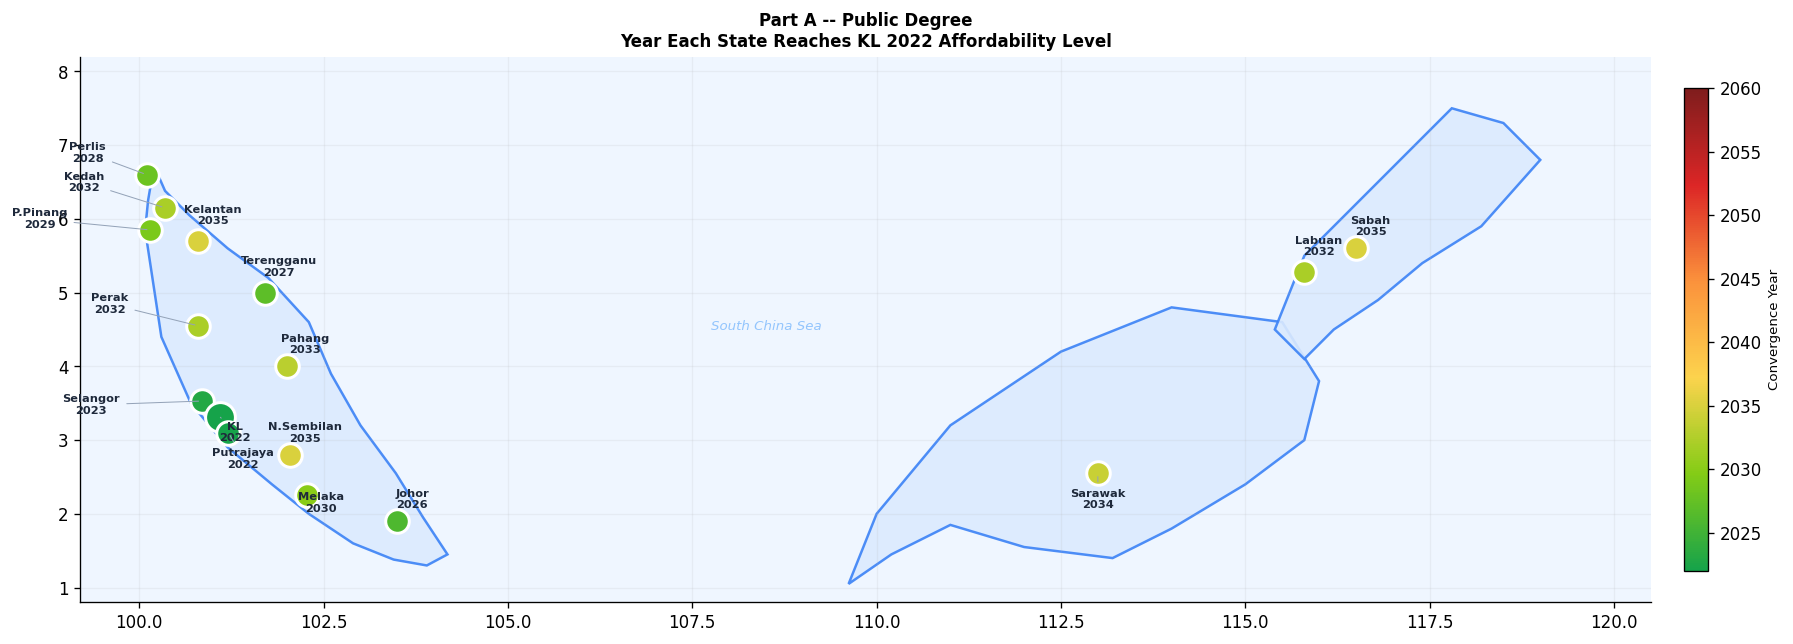

In [50]:
STATE_COORDS = {
    'Perlis':            (100.10, 6.60), 'Kedah':             (100.35, 6.15),
    'Pulau Pinang':      (100.15, 5.85), 'Perak':             (100.80, 4.55),
    'Selangor':          (100.85, 3.53), 'W.P. Kuala Lumpur': (101.10, 3.31),
    'W.P. Putrajaya':    (101.21, 3.10), 'Negeri Sembilan':   (102.05, 2.80),
    'Melaka':            (102.27, 2.25), 'Johor':             (103.50, 1.90),
    'Pahang':            (102.00, 4.00), 'Terengganu':        (101.70, 5.00),
    'Kelantan':          (100.80, 5.70), 'Sarawak':           (113.00, 2.55),
    'Sabah':             (116.50, 5.60), 'W.P. Labuan':       (115.80, 5.28),
}
LABEL_OFFSET = {
    'Perlis':(-0.8,0.15),'Kedah':(-1.1,0.20),'Pulau Pinang':(-1.5,0.0),
    'Perak':(-1.2,0.15),'Selangor':(-1.5,-0.20),'W.P. Kuala Lumpur':(0.20,-0.35),
    'W.P. Putrajaya':(0.20,-0.50),'Negeri Sembilan':(0.20,0.15),'Melaka':(0.20,-0.25),
    'Johor':(0.20,0.15),'Pahang':(0.25,0.15),'Terengganu':(0.20,0.20),
    'Kelantan':(0.20,0.20),'Sarawak':(0.0,-0.50),'Sabah':(0.20,0.15),'W.P. Labuan':(0.20,0.20),
}
pen_x=[100.08,100.12,100.20,100.35,100.68,101.20,101.75,102.30,102.60,103.00,103.48,103.85,104.18,103.90,103.45,102.90,102.30,101.80,101.20,100.70,100.30,100.08]
pen_y=[5.85,6.25,6.72,6.38,6.05,5.60,5.20,4.60,3.90,3.20,2.55,1.95,1.45,1.30,1.38,1.60,2.00,2.40,2.90,3.50,4.40,5.85]
sar_x=[109.62,110.20,111.00,112.00,113.20,114.00,115.00,115.80,116.00,115.50,114.00,112.50,111.00,110.00,109.62]
sar_y=[1.05,1.45,1.85,1.55,1.40,1.80,2.40,3.00,3.80,4.60,4.80,4.20,3.20,2.00,1.05]
sab_x=[115.80,116.20,116.80,117.40,118.20,119.00,118.50,117.80,116.80,115.80,115.40,115.80]
sab_y=[4.10,4.50,4.90,5.40,5.90,6.80,7.30,7.50,6.50,5.50,4.50,4.10]

all_conv_pub = dict(zip(pub_conv_df['state'], pub_conv_df['conv_year']))
all_conv_pub['W.P. Kuala Lumpur'] = 2022

def draw_map(ax, all_conv, vmin, vmax, title):
    cmap_map = LinearSegmentedColormap.from_list('conv',
        ['#16A34A','#84CC16','#FCD34D','#FB923C','#DC2626','#7F1D1D'], N=256)
    norm_map = mcolors.Normalize(vmin=vmin, vmax=vmax)
    def year_color(yr):
        if yr is None or yr > vmax: return '#7F1D1D'
        return mcolors.to_hex(cmap_map(norm_map(yr)))
    ax.set_facecolor('#EFF6FF')
    ax.set_aspect('equal')
    for xs, ys in [(pen_x,pen_y),(sar_x,sar_y),(sab_x,sab_y)]:
        ax.fill(xs, ys, color='#DBEAFE', edgecolor='#3B82F6', lw=1.5, zorder=1, alpha=0.9)
    ax.text(108.5, 4.5, 'South China Sea', fontsize=8, color='#93C5FD',
            style='italic', ha='center', zorder=2)
    for state, (lon, lat) in STATE_COORDS.items():
        color = year_color(all_conv.get(state))
        size  = 320 if 'Kuala Lumpur' in state else 200
        ax.scatter(lon, lat, s=size, color=color, edgecolors='white', lw=1.8, zorder=5)
        yr_lbl= str(int(all_conv[state])) if all_conv.get(state) and all_conv[state]<9000 else '>'+str(vmax)
        short = (state.replace('W.P. Kuala Lumpur','KL').replace('W.P. Putrajaya','Putrajaya')
                 .replace('W.P. Labuan','Labuan').replace('Negeri Sembilan','N.Sembilan')
                 .replace('Pulau Pinang','P.Pinang'))
        dx, dy = LABEL_OFFSET.get(state, (0.20,0.15))
        ax.annotate(f'{short}\n{yr_lbl}', xy=(lon,lat), xytext=(lon+dx, lat+dy),
                    fontsize=6.8, fontweight='bold', color='#1E293B',
                    ha='center', va='bottom', zorder=6,
                    arrowprops=dict(arrowstyle='-', color='#94A3B8', lw=0.6)
                    if abs(dx)>0.3 or abs(dy)>0.25 else None)
    sm = ScalarMappable(cmap=cmap_map, norm=norm_map)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.022, pad=0.02, shrink=0.6)
    cbar.set_label('Convergence Year', fontsize=8)
    ax.set_xlim(99.2, 120.5); ax.set_ylim(0.8, 8.2)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.15)

fig, ax = plt.subplots(figsize=(15, 7))
draw_map(ax, all_conv_pub, 2022, 2060,
         'Part A -- Public Degree\nYear Each State Reaches KL 2022 Affordability Level')
plt.tight_layout()
plt.show()


---
# Part B -- Private University Pathway

A significant share of Malaysian graduates attend private universities.
This section examines how the affordability burden differs for this group
and how long convergence takes under private fee assumptions.

The benchmark is KL's public degree affordability level in 2022.
This answers: when can families on the private pathway reach the same level of
financial sacrifice that KL families currently make for a public degree?

**Limitation:** Fee data covers only APU and Taylor's -- both premium-tier institutions.
The private fee used here (RM 119k) is an upper bound. The actual average across
all private universities in Malaysia is lower, meaning the true burden lies somewhere
between the public and private bars shown. The direction of the finding holds regardless.


## B1 -- Public vs Private Affordability Side by Side (2022)

Shows the gap in affordability burden between the two pathways for every state.
The gap reflects the cost difference between public and private institutions.

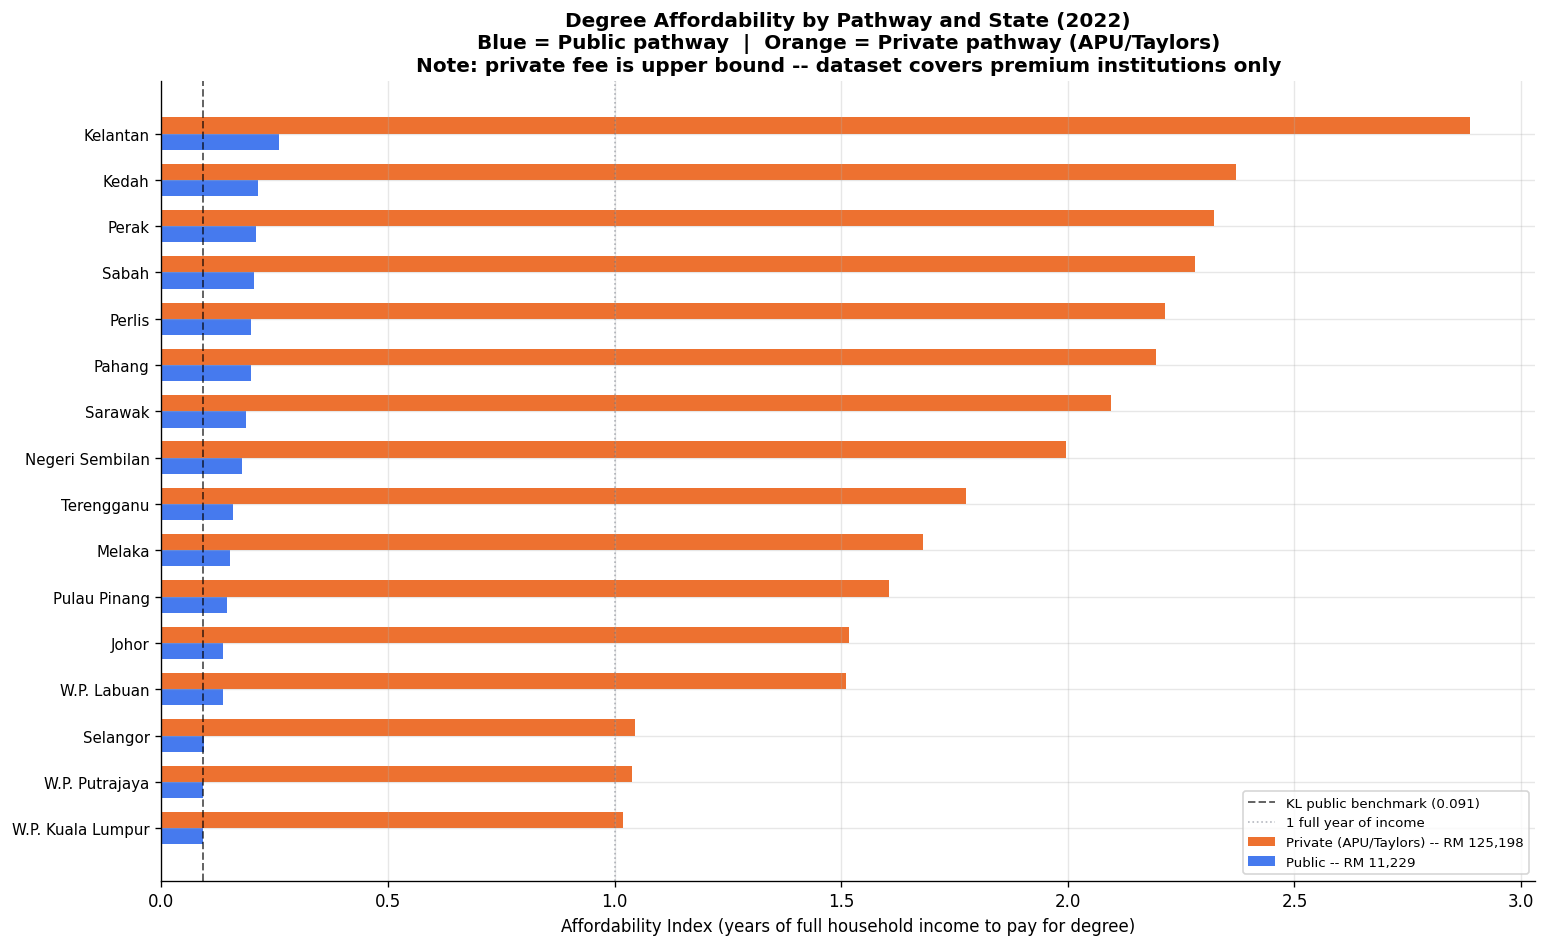

In [28]:
hh_2022_sorted = hh_2022.sort_values('aff_private', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))
y = np.arange(len(hh_2022_sorted))
h = 0.35

ax.barh(y + h/2, hh_2022_sorted['aff_private'], h, color=ORANGE, alpha=0.85,
        label=f'Private (APU/Taylors) -- RM {PRIVATE_FEE:,.0f}')
ax.barh(y - h/2, hh_2022_sorted['aff_public'],  h, color=BLUE,   alpha=0.85,
        label=f'Public -- RM {PUBLIC_FEE:,.0f}')

ax.set_yticks(y)
ax.set_yticklabels(hh_2022_sorted['state'], fontsize=9)
ax.set_xlabel('Affordability Index (years of full household income to pay for degree)')
ax.set_title('Degree Affordability by Pathway and State (2022)\n'
             'Blue = Public pathway  |  Orange = Private pathway (APU/Taylors)\n'
             'Note: private fee is upper bound -- dataset covers premium institutions only',
             fontweight='bold', fontsize=12)
ax.axvline(KL_PUBLIC_2022, color='black', lw=1.2, ls='--', alpha=0.6,
           label=f'KL public benchmark ({KL_PUBLIC_2022:.3f})')
ax.axvline(1.0, color=GRAY, lw=1.0, ls=':', alpha=0.5, label='1 full year of income')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()


## B2 -- Private Pathway Convergence Chart

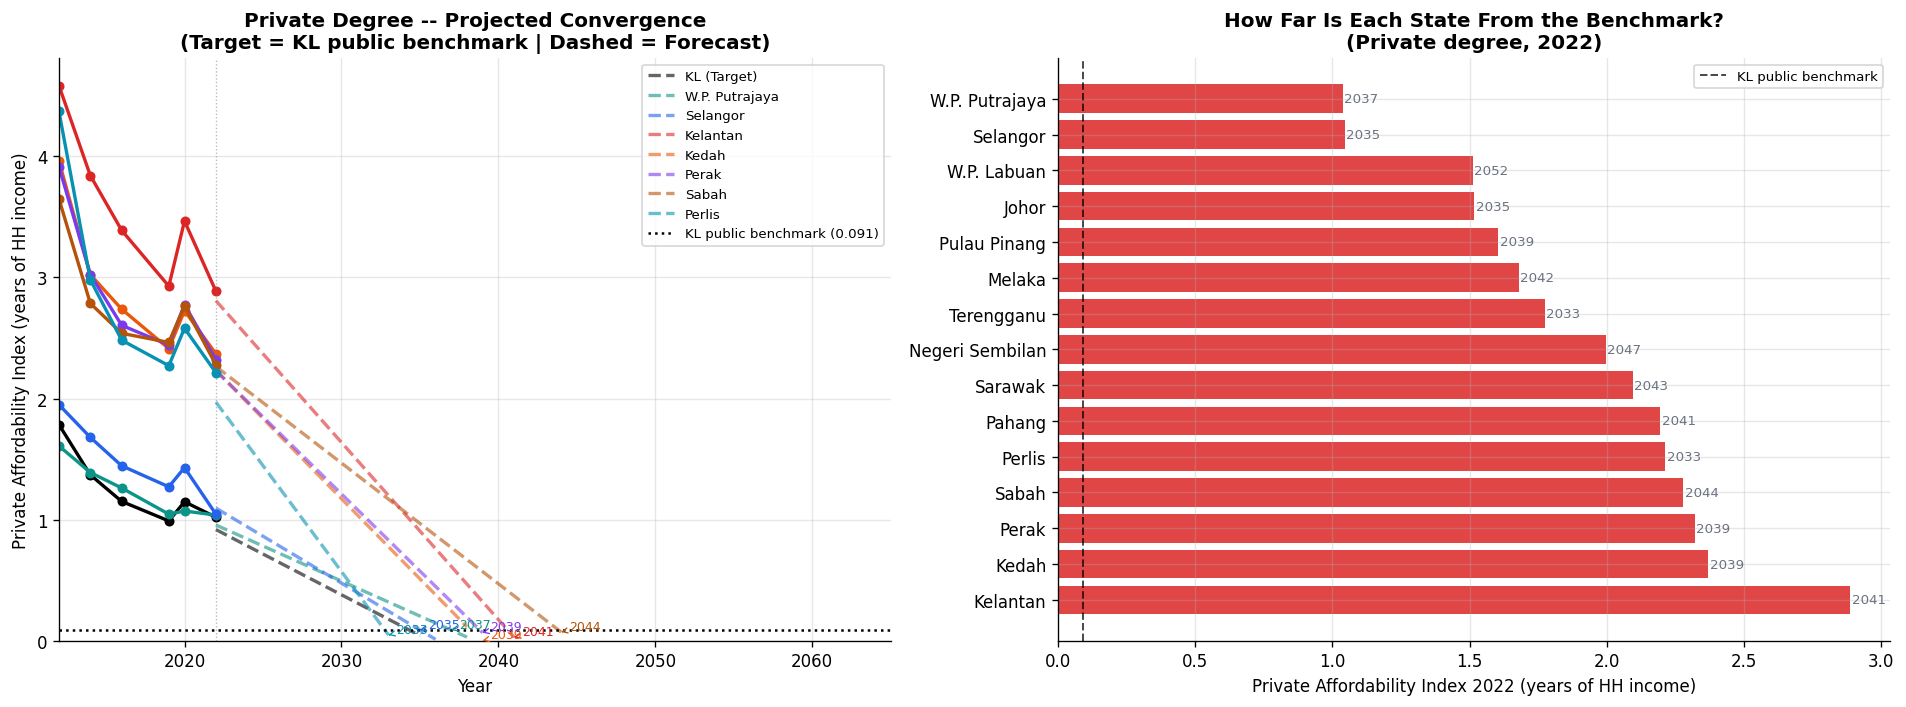

In [29]:
prv_trends = {}
for state in hh_state['state'].unique():
    df_s  = aff_df[aff_df['state']==state].sort_values('year')
    X     = df_s['year'].values.reshape(-1,1)
    y_arr = df_s['aff_private'].values
    model = LinearRegression().fit(X, y_arr)
    prv_trends[state] = {'model': model, 'data': df_s}

prv_conv = []
for state, t in prv_trends.items():
    if state == 'W.P. Kuala Lumpur': continue
    proj    = t['model'].predict(PROJ_YEARS.reshape(-1,1))
    crossed = PROJ_YEARS[proj <= KL_PUBLIC_2022]
    conv_yr = int(crossed[0]) if len(crossed) > 0 else None
    aff22   = aff_df[(aff_df['state']==state)&(aff_df['year']==2022)]['aff_private'].values[0]
    prv_conv.append({'state': state, 'aff_2022': aff22, 'conv_year': conv_yr})

prv_conv_df = pd.DataFrame(prv_conv).sort_values('aff_2022', ascending=False)
worst5_p = prv_conv_df.nlargest(5,  'aff_2022')['state'].tolist()
best2_p  = prv_conv_df.nsmallest(2, 'aff_2022')['state'].tolist()
focus_p  = ['W.P. Kuala Lumpur'] + best2_p + worst5_p
palette  = ['black', TEAL, BLUE, RED, ORANGE, PURPLE, '#B45309', '#0891B2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, state in enumerate(focus_p):
    t     = prv_trends[state]
    hist  = aff_df[aff_df['state']==state].sort_values('year')
    proj  = t['model'].predict(PROJ_YEARS.reshape(-1,1))
    proj_c= np.maximum(proj, 0)
    color = palette[i % len(palette)]
    lbl   = 'KL (Target)' if state=='W.P. Kuala Lumpur' else state
    mask  = (PROJ_YEARS <= 2065) & (proj >= 0)

    axes[0].plot(hist['year'], hist['aff_private'],
                 color=color, lw=2, marker='o', markersize=5)
    axes[0].plot(PROJ_YEARS[mask], proj_c[mask],
                 color=color, lw=2, ls='--', alpha=0.6, label=lbl)

    row = prv_conv_df[prv_conv_df['state']==state]
    if not row.empty and row['conv_year'].values[0]:
        cy = row['conv_year'].values[0]
        if cy <= 2065:
            cv = max(t['model'].predict([[cy]])[0], 0)
            axes[0].annotate(f'{cy}', xy=(cy,cv), xytext=(cy+0.5, cv+0.02),
                fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

axes[0].axhline(KL_PUBLIC_2022, color='black', lw=1.5, ls=':',
                label=f'KL public benchmark ({KL_PUBLIC_2022:.3f})')
axes[0].axvline(2022, color=GRAY, lw=0.8, ls=':', alpha=0.5)
axes[0].set_ylim(bottom=0)
axes[0].set_xlim(2012, 2065)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Private Affordability Index (years of HH income)')
axes[0].set_title('Private Degree -- Projected Convergence\n'
                  '(Target = KL public benchmark | Dashed = Forecast)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

gap_p = prv_conv_df.sort_values('aff_2022', ascending=False)
colors_g = [RED if v > 0.5 else ORANGE if v > 0.3 else GREEN for v in gap_p['aff_2022']]
bars = axes[1].barh(gap_p['state'], gap_p['aff_2022'], color=colors_g, alpha=0.85)
axes[1].axvline(KL_PUBLIC_2022, color='black', lw=1.2, ls='--', alpha=0.7,
                label=f'KL public benchmark')
axes[1].set_xlabel('Private Affordability Index 2022 (years of HH income)')
axes[1].set_title('How Far Is Each State From the Benchmark?\n(Private degree, 2022)',
                  fontweight='bold')
axes[1].legend(fontsize=8)
for bar, (_, row) in zip(bars, gap_p.iterrows()):
    lbl = f"{int(row['conv_year'])}" if row['conv_year'] else '>2070'
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 lbl, va='center', fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()


## B3 -- Malaysia Map: Public vs Private Convergence Year Side by Side

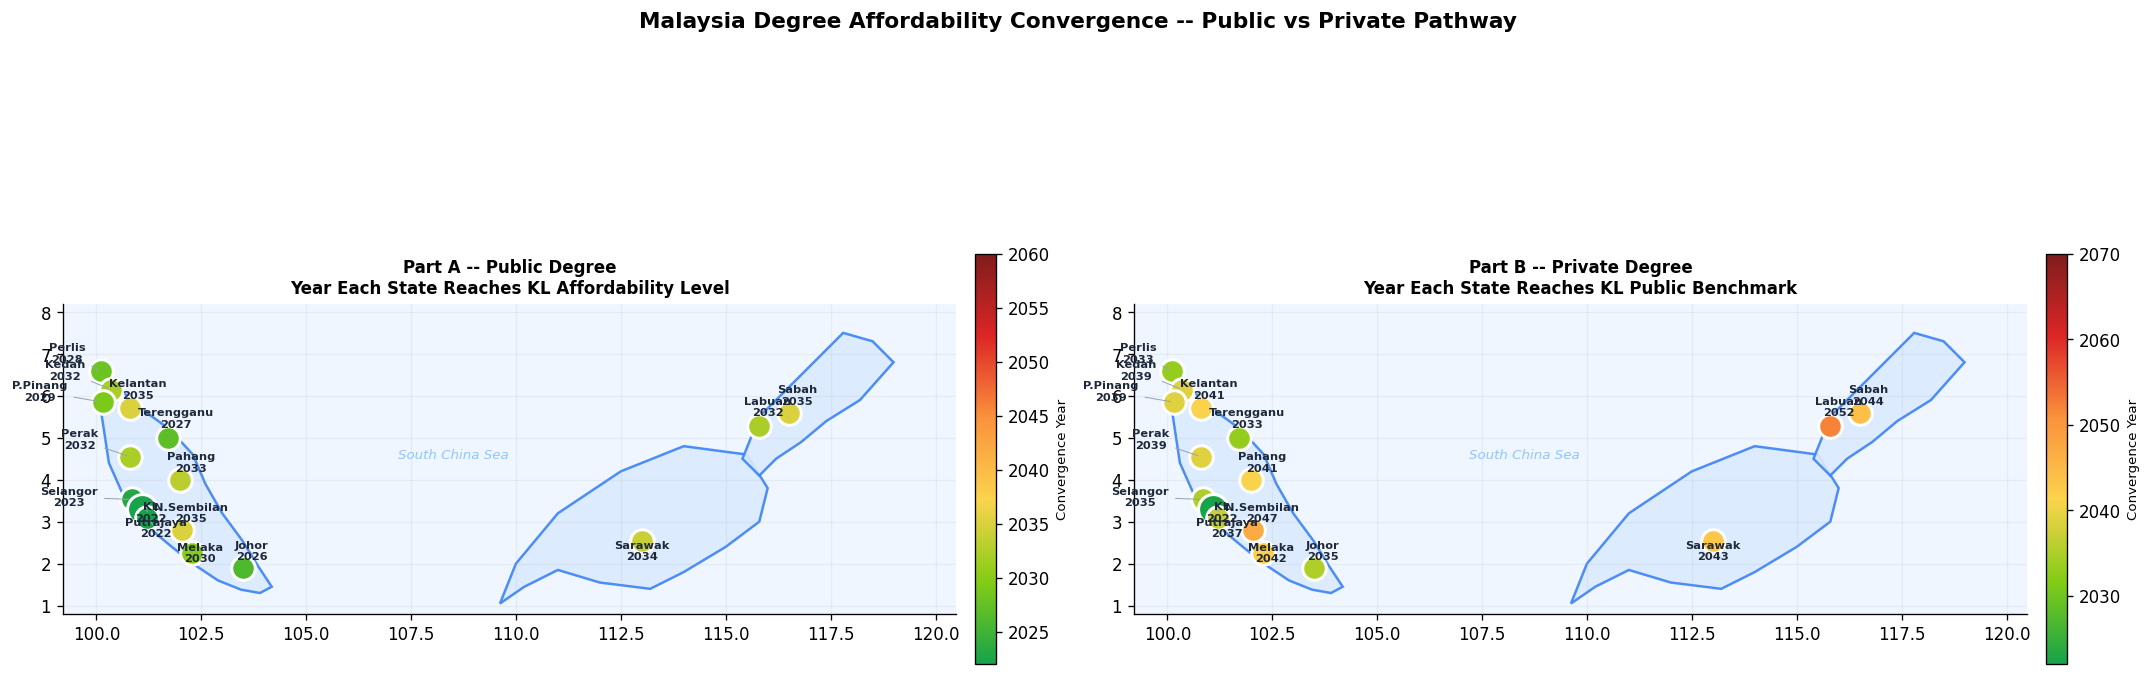

Placing both maps side by side makes the gap immediately visible:
The private pathway map should be significantly darker/redder than the public one.


In [51]:
all_conv_prv = dict(zip(prv_conv_df['state'], prv_conv_df['conv_year']))
all_conv_prv['W.P. Kuala Lumpur'] = 2022

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
draw_map(axes[0], all_conv_pub, 2022, 2060,
         'Part A -- Public Degree\nYear Each State Reaches KL Affordability Level')
draw_map(axes[1], all_conv_prv, 2022, 2070,
         'Part B -- Private Degree\nYear Each State Reaches KL Public Benchmark')
plt.suptitle('Malaysia Degree Affordability Convergence -- Public vs Private Pathway',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Placing both maps side by side makes the gap immediately visible:")
print("The private pathway map should be significantly darker/redder than the public one.")


---
## Combined Summary & So What

In [31]:
print("=" * 65)
print("COMBINED FINDINGS -- PARTS A AND B")
print("=" * 65)
print()
print("Part A -- Public pathway:")
for _, row in pub_conv_df.nlargest(3, 'aff_2022').iterrows():
    cy = row['conv_year']
    print(f"  {row['state']:<22} index {row['aff_2022']:.3f}  converges {int(cy) if cy else '>2070'}")
print()
print("Part B -- Private pathway (mid estimate):")
for _, row in prv_conv_df.nlargest(3, 'aff_2022').iterrows():
    cy = row['conv_year']
    print(f"  {row['state']:<22} index {row['aff_2022']:.3f}  converges {int(cy) if cy else '>2070'}")
print()
print("=" * 65)
print("INTERPRETATION")
print("-" * 65)
print("Affordability improved from 2012 to 2022 across all states,")
print("driven by household income growing faster than fees.")
print()
print("However, the improvement is unequal by geography -- families")
print("in lower-income states start from a much higher burden and")
print("will take significantly longer to reach KL's level.")
print()
print("For the private pathway, the burden is substantially heavier")
print("across all states. Even the most affordable state faces a")
print("private degree cost that is well above the KL public benchmark,")
print("and convergence -- if it happens at all -- takes decades longer.")
print()
print("SO WHAT")
print("-" * 65)
print("1. A uniform fee structure does not produce uniform outcomes.")
print("   Families in lower-income states sacrifice proportionally")
print("   more for the same degree, regardless of which pathway.")
print()
print("2. The gap between public and private affordability is not")
print("   a small difference -- it represents fundamentally different")
print("   financial realities for families on the same income.")
print()
print("3. Policy that targets only national-level affordability misses")
print("   the regional and pathway dimensions entirely.")

os.makedirs('../data/analysis', exist_ok=True)
pub_conv_df.to_csv('../data/analysis/state_convergence_public.csv', index=False)
prv_conv_df.to_csv('../data/analysis/state_convergence_private.csv', index=False)
aff_df.to_csv('../data/analysis/state_affordability_index.csv', index=False)
print("\nSaved outputs to ../data/analysis/")


COMBINED FINDINGS -- PARTS A AND B

Part A -- Public pathway:
  Kelantan               index 0.259  converges 2035
  Kedah                  index 0.213  converges 2032
  Perak                  index 0.208  converges 2032

Part B -- Private pathway (mid estimate):
  Kelantan               index 2.887  converges 2041
  Kedah                  index 2.370  converges 2039
  Perak                  index 2.322  converges 2039

INTERPRETATION
-----------------------------------------------------------------
Affordability improved from 2012 to 2022 across all states,
driven by household income growing faster than fees.

However, the improvement is unequal by geography -- families
in lower-income states start from a much higher burden and
will take significantly longer to reach KL's level.

For the private pathway, the burden is substantially heavier
across all states. Even the most affordable state faces a
private degree cost that is well above the KL public benchmark,
and convergence -- if it 